In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()
input_name = next(iter(uploaded))
input_path = '/content/' + input_name

print('Input Image:', input_name)

Saving notes.png to notes.png
Input Image: notes.png


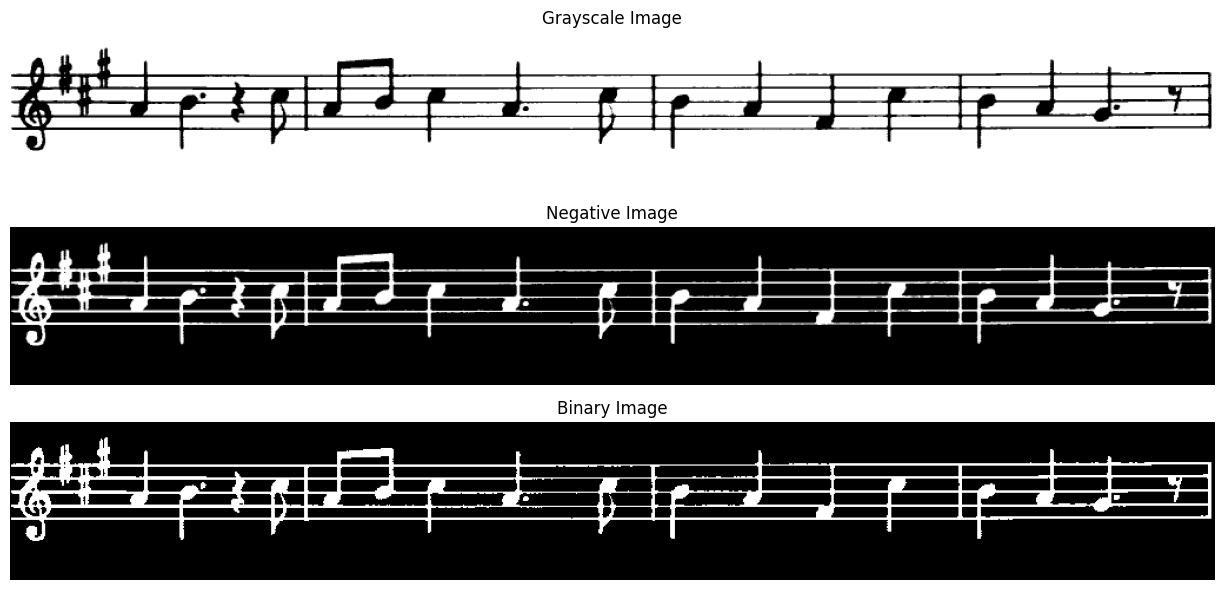

In [3]:
gray_image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
if gray_image is None:
  raise ValueError('Invalid Image')

negative_image = cv2.bitwise_not(gray_image)
binary_image = cv2.adaptiveThreshold(negative_image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 15, -2)

plt.figure(figsize=(17, 6))

plt.subplot(3, 1, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(3, 1, 2)
plt.imshow(negative_image, cmap='gray')
plt.title('Negative Image')
plt.axis('off')

plt.subplot(3, 1, 3)
plt.imshow(binary_image, cmap='gray')
plt.title('Binary Image')
plt.axis('off')

plt.tight_layout()
plt.show()

Horizontal Structure:
[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]


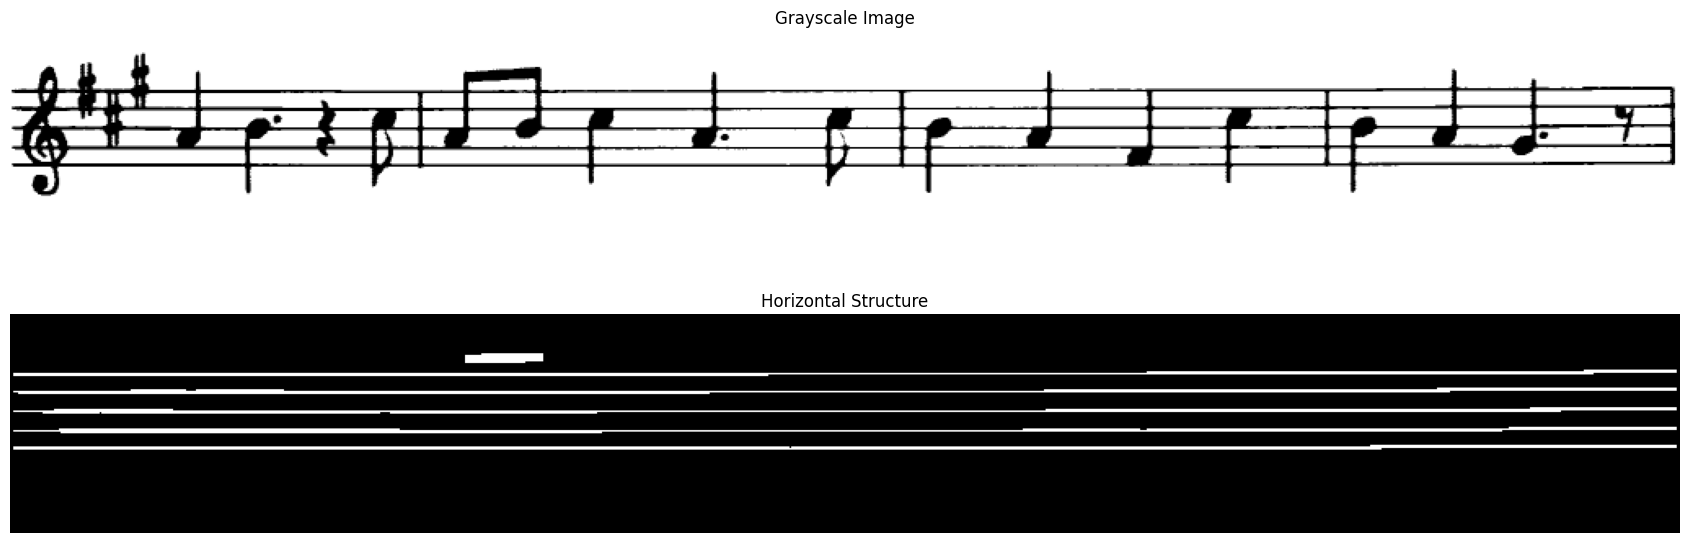

In [4]:
cols = binary_image.shape[1]
horizontal_size = cols // 30
horizontal_structure = cv2.getStructuringElement(cv2.MORPH_RECT, (horizontal_size, 1))

print('Horizontal Structure:')
print(horizontal_structure)

horizonal = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, horizontal_structure)

plt.figure(figsize=(17, 6))

plt.subplot(2, 1, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(horizonal, cmap='gray')
plt.title('Horizontal Structure')
plt.axis('off')

plt.tight_layout()
plt.show()

Vertical Structure:
[[1]
 [1]
 [1]
 [1]]


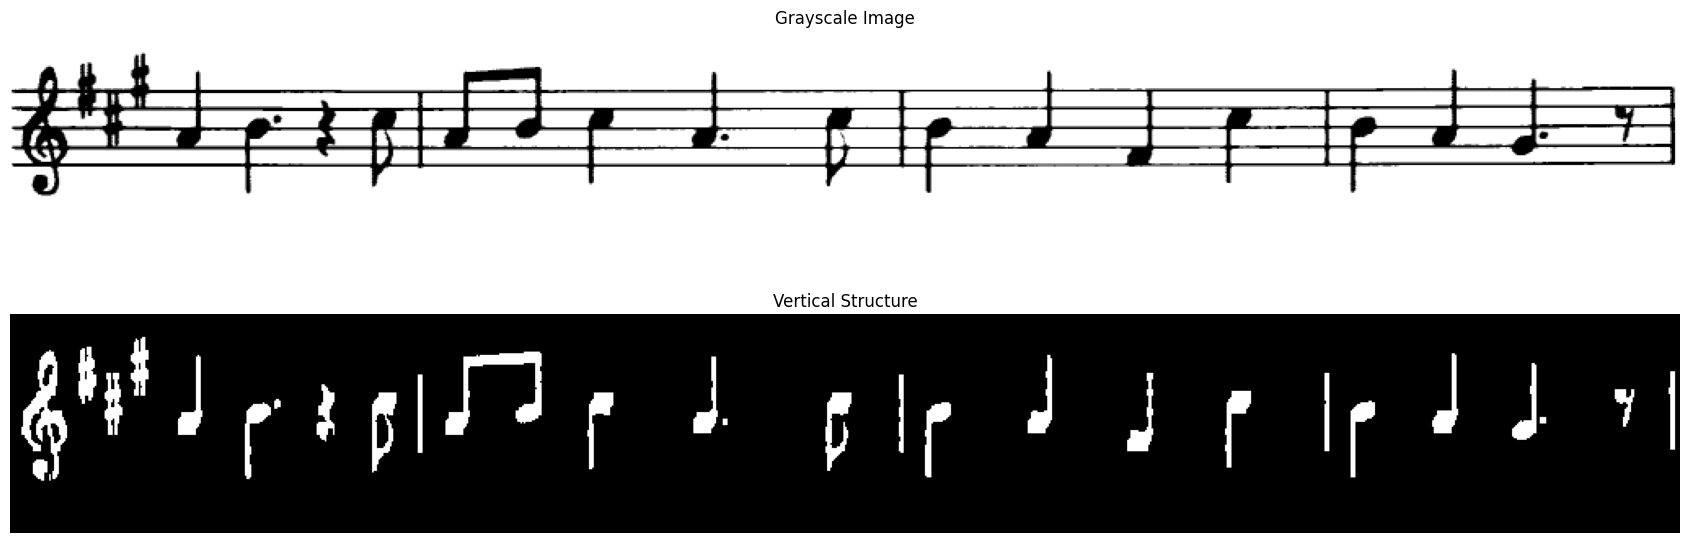

In [5]:
rows = gray_image.shape[0]
vertical_size = rows // 30
vertical_structure = cv2.getStructuringElement(cv2.MORPH_RECT, (1, vertical_size))

print('Vertical Structure:')
print(vertical_structure)

vertical = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, vertical_structure)

plt.figure(figsize=(17, 6))

plt.subplot(2, 1, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(vertical, cmap='gray')
plt.title('Vertical Structure')
plt.axis('off')

plt.tight_layout()
plt.show()

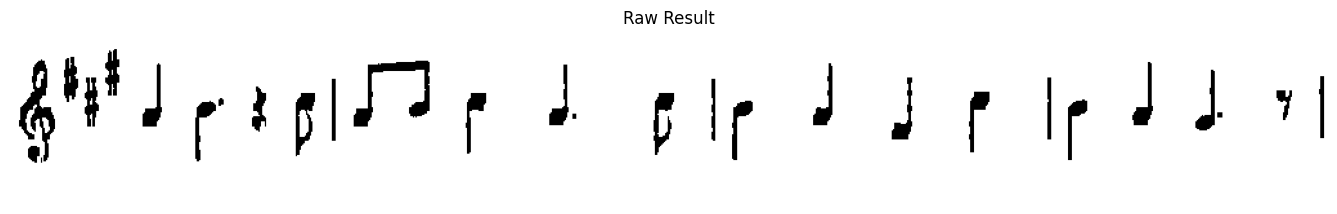

In [6]:
raw_result = cv2.bitwise_not(vertical)

plt.figure(figsize=(17, 6))

plt.imshow(raw_result, cmap='gray')
plt.title('Raw Result')
plt.axis('off')

plt.show()

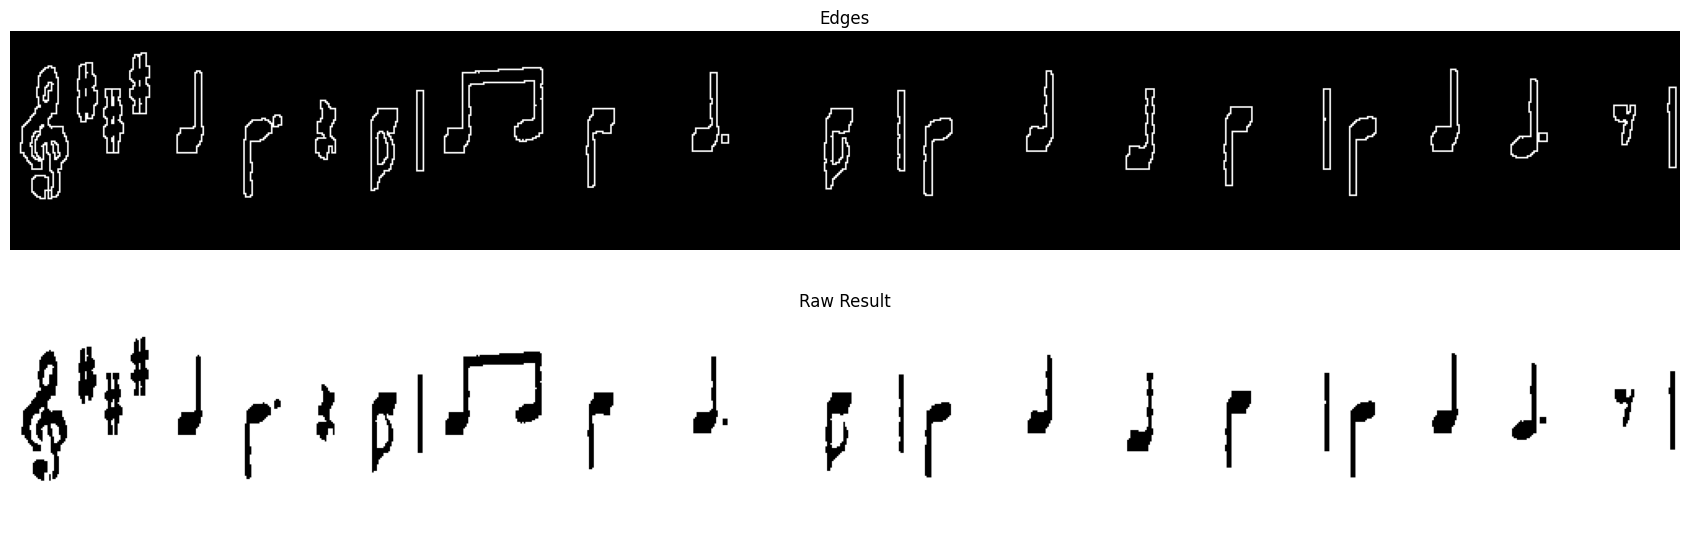

In [7]:
edges = cv2.adaptiveThreshold(raw_result, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 3, -2)

plt.figure(figsize=(17, 6))

plt.subplot(2, 1, 1)
plt.imshow(edges, cmap='gray')
plt.title('Edges')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(raw_result, cmap='gray')
plt.title('Raw Result')
plt.axis('off')

plt.tight_layout()
plt.show()

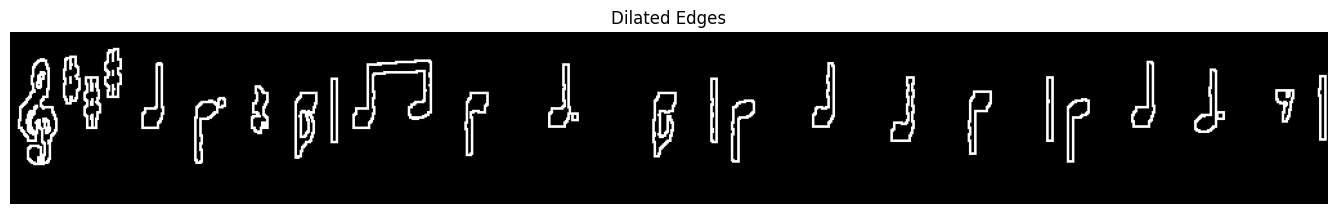

In [8]:
kernel = np.ones((2, 2), np.uint8)
edges = cv2.dilate(edges, kernel)

plt.figure(figsize=(17, 6))

plt.imshow(edges, cmap='gray')
plt.title('Dilated Edges')
plt.axis('off')

plt.show()

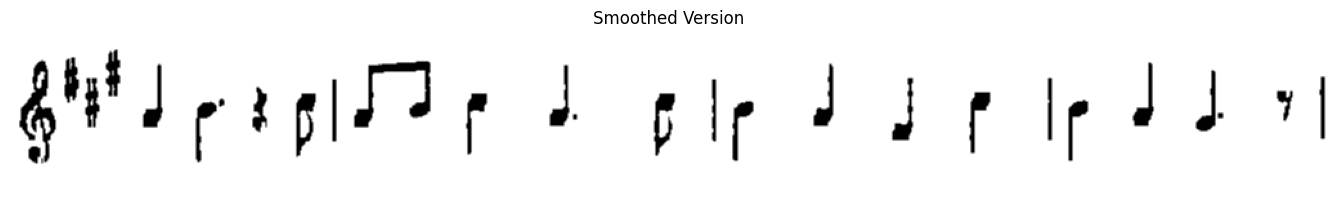

In [9]:
smooth = cv2.blur(raw_result, (2, 2))

plt.figure(figsize=(17, 6))

plt.imshow(smooth, cmap='gray')
plt.title('Smoothed Version')
plt.axis('off')

plt.show()

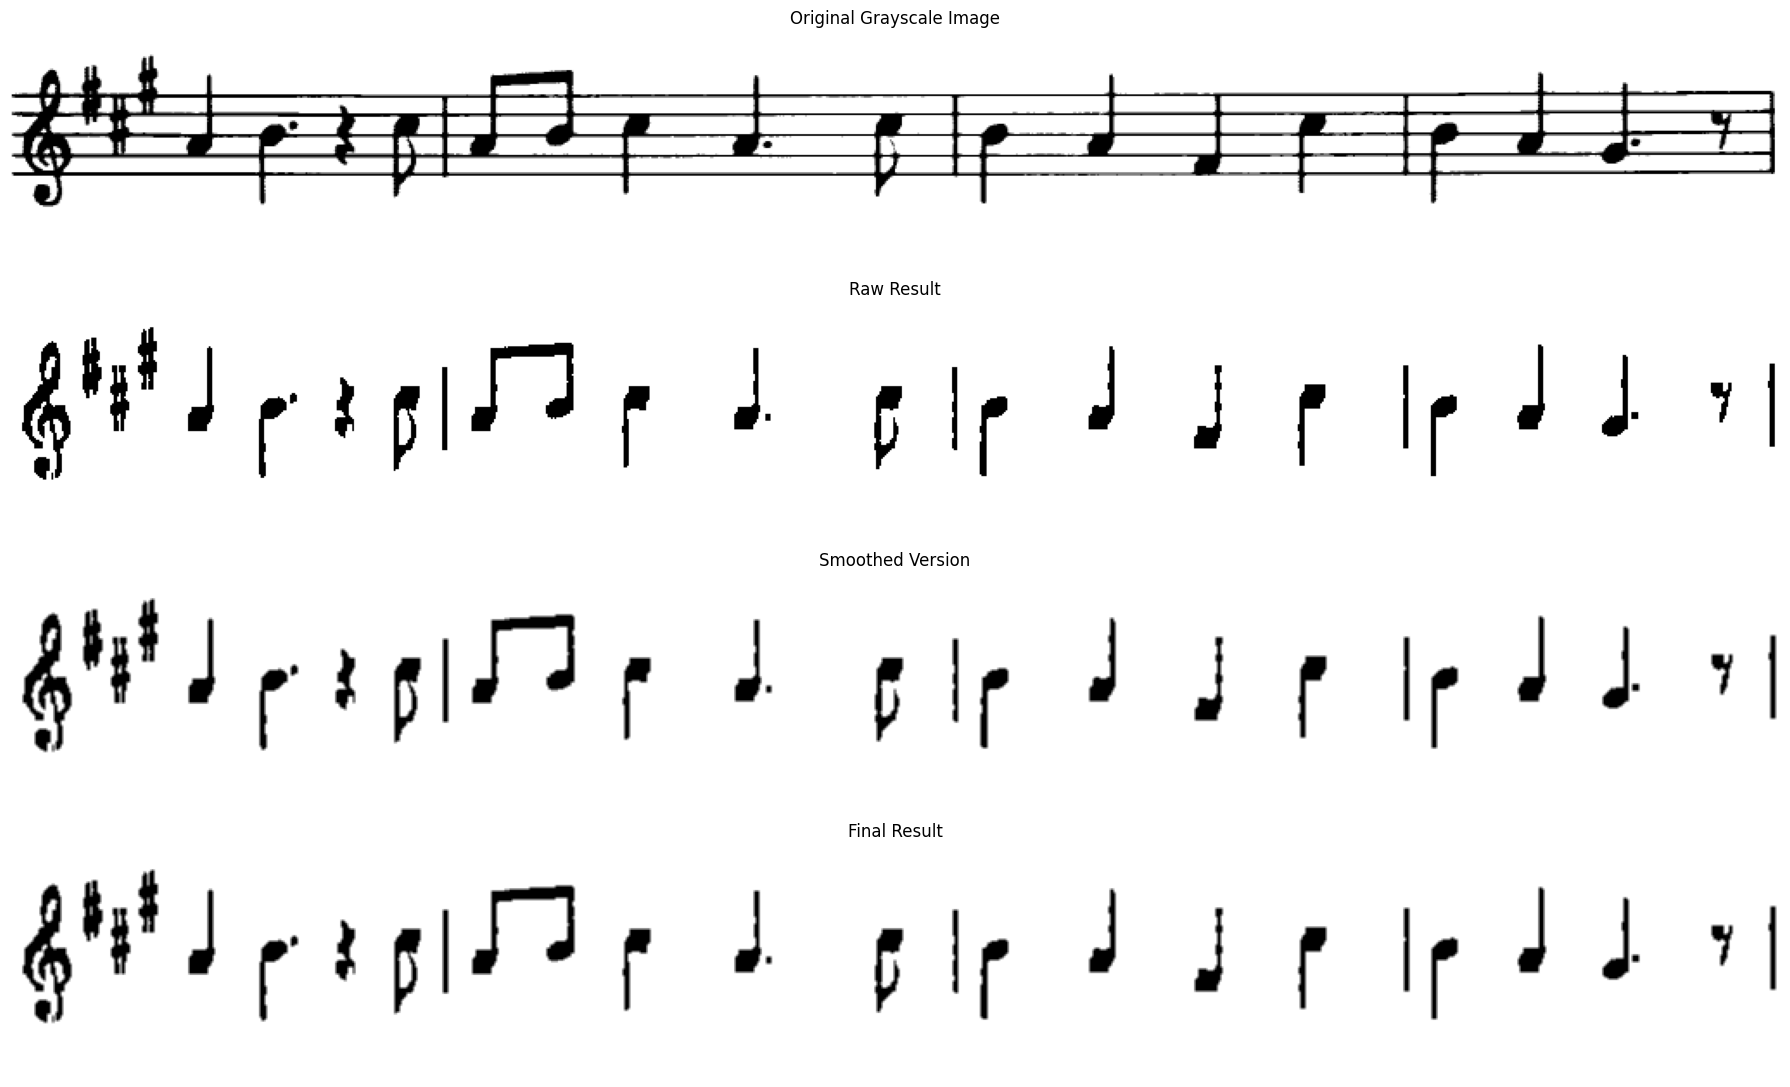

In [12]:
rows_indices, cols_indices = np.where(edges != 0)
final_result = np.copy(raw_result)
final_result[rows_indices, cols_indices] = smooth[rows_indices, cols_indices]

plt.figure(figsize=(18, 11))

plt.subplot(4, 1, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(4, 1, 2)
plt.imshow(raw_result, cmap='gray')
plt.title('Raw Result')
plt.axis('off')

plt.subplot(4, 1, 3)
plt.imshow(smooth, cmap='gray')
plt.title('Smoothed Version')
plt.axis('off')

plt.subplot(4, 1, 4)
plt.imshow(final_result, cmap='gray')
plt.title('Final Result')
plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
output_paths = {
    'horizontal_lines.png': horizonal,
    'vertical_lines.png': vertical,
    'raw_result.png': raw_result,
    'final_result.png': final_result,
}

for filename, output_image in output_paths.items():
  output_path = '/content/' + filename
  cv2.imwrite(output_path, output_image)
  files.download(output_path)
  print('Saved:', filename)
  print('Downloaded:', filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: horizontal_lines.png
Downloaded: horizontal_lines.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Saved: raw_result.png
Downloaded: raw_result.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved: final_result.png
Downloaded: final_result.png
